Regiones Fronteras y Conteo

Num de regiones detectadas inicialmente: 12

region 1 (válida):
  - Num pixeles: 511541
  - Cantidad de colores distintos: 81
  - Color promedio(BGR): [221.68943447 224.96302545 228.83180234]

region 2 (válida):
  - Num pixeles: 651
  - Cantidad de colores distintos: 14
  - Color promedio(BGR): [240.16436252 238.9093702  227.07834101]

region 3 (válida):
  - Num pixeles: 722
  - Cantidad de colores distintos: 15
  - Color promedio(BGR): [240.5734072  236.7299169  222.71191136]

region 6 (válida):
  - Num pixeles: 6530
  - Cantidad de colores distintos: 21
  - Color promedio(BGR): [202.32695253 204.65222052 209.89617152]

region 7 (válida):
  - Num pixeles: 57
  - Cantidad de colores distintos: 1
  - Color promedio(BGR): [135.33333333 136.0877193  150.75438596]

Num de regiones válidas (después de filtrar el ruido): 5


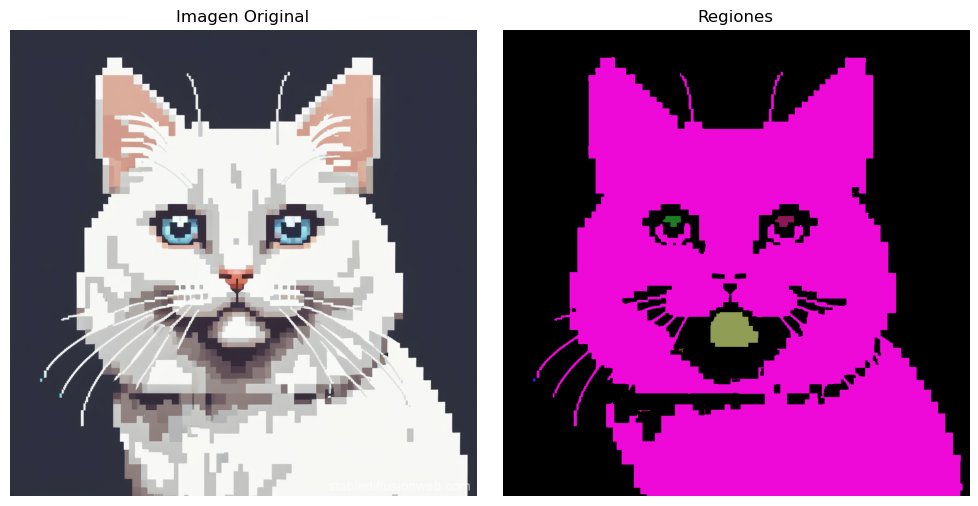

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

img = cv2.imread('imagen1.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

_, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

kernel = np.ones((5,5), np.uint8)
binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

labels = measure.label(binary, connectivity=2)
num_regiones = np.max(labels)

print(f"Num de regiones detectadas inicialmente: {num_regiones}")
regiones_validas = 0 

for i in range(1, num_regiones + 1):

    mask = (labels == i)
    num_pixels = np.sum(mask)

    if num_pixels < 50:
        continue 


    regiones_validas += 1
    region_pixels = img[mask]
    avg_color = np.mean(region_pixels, axis=0)
    
    # Reducción redundante de reshape ajustada
    region_pixels_reduced = (region_pixels // 32) * 32
    unique_colors = np.unique(region_pixels_reduced, axis=0)
    num_colores = len(unique_colors)

    print(f"\nregion {i} (válida):")
    print(f"  - Num pixeles: {num_pixels}")
    print(f"  - Cantidad de colores distintos: {num_colores}")
    print(f"  - Color promedio(BGR): {avg_color}")

print(f"\nNum de regiones válidas (después de filtrar el ruido): {regiones_validas}")

colors = np.random.randint(0, 255, size=(num_regiones + 1, 3), dtype=np.uint8)
colors[0] = [0, 0, 0] # El fondo se queda en negro
colored_img = colors[labels]

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title('Imagen Original')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1,2,2)
plt.title('Regiones')
plt.imshow(colored_img)
plt.axis('off')

plt.tight_layout()
plt.show()
